In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('/home/aniketnerali16/new/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Shape: (7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("===Data Types-===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

===Data Types-===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pape

In [4]:


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0)

print("Fixed! TotalCharges dtype:", df['TotalCharges'].dtype)
print("Nulls remaning:", df['TotalCharges'].isnull().sum())


Fixed! TotalCharges dtype: float64
Nulls remaning: 11


=== Churn Counts ===
<bound method IndexOpsMixin.value_counts of 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str>

=== Churn Percentage ===
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


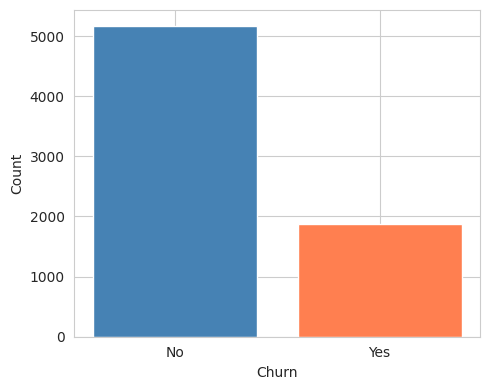

In [17]:
churn_counts = df['Churn'].value_counts
churn_pct = df['Churn'].value_counts(normalize=True)*100
no_count = (df['Churn'] == 'No').sum()
yes_count = (df['Churn'] == 'Yes').sum()

print("=== Churn Counts ===")
print(churn_counts)
print("\n=== Churn Percentage ===")
print(churn_pct)

plt.figure(figsize=(5, 4))
plt.bar(['No', 'Yes'], [no_count, yes_count], color=['steelblue', 'coral'])
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


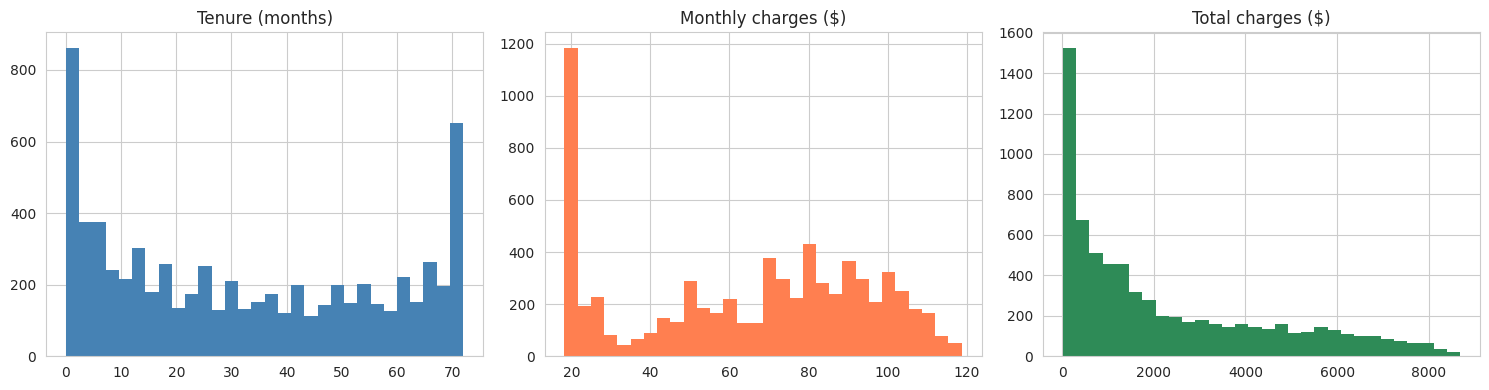

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['tenure'].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='none')
axes[0].set_title('Tenure (months)')

df['MonthlyCharges'].hist(ax=axes[1], bins=30, color='coral', edgecolor='none')
axes[1].set_title('Monthly charges ($)')

df['TotalCharges'].hist(ax=axes[2], bins=30, color='seagreen', edgecolor='none')
axes[2].set_title('Total charges ($)')

plt.tight_layout()
plt.show()



In [21]:
print("=== Avg Value for Churned VS Non- Churned ====")
df.groupby('Churn')[['tenure','MonthlyCharges', 'TotalCharges' ]].mean().round(2)

=== Avg Value for Churned VS Non- Churned ====


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


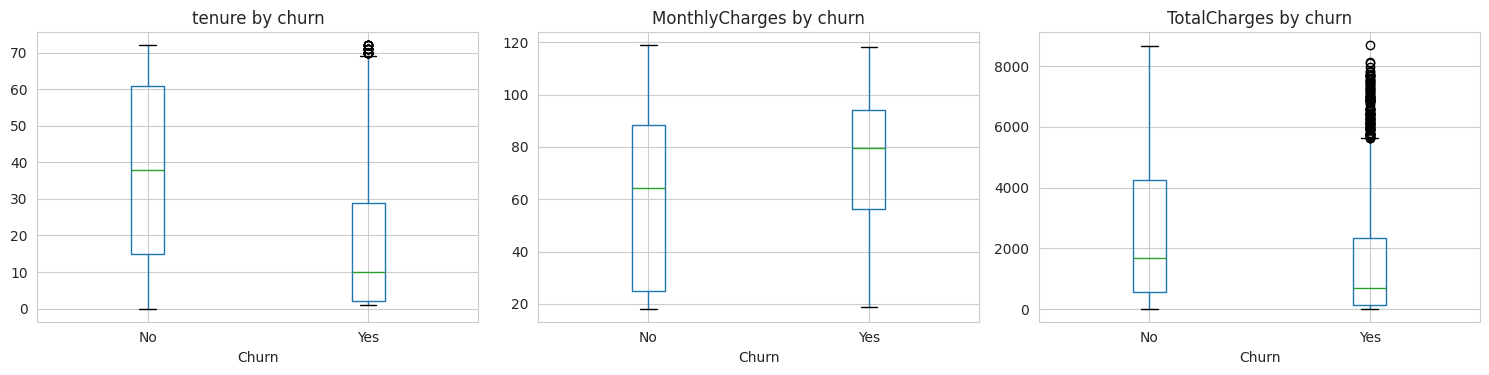

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, 
                           ['tenure', 'MonthlyCharges', 'TotalCharges'],
                           ['steelblue', 'coral', 'seagreen']):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} by churn')
    ax.set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.show()

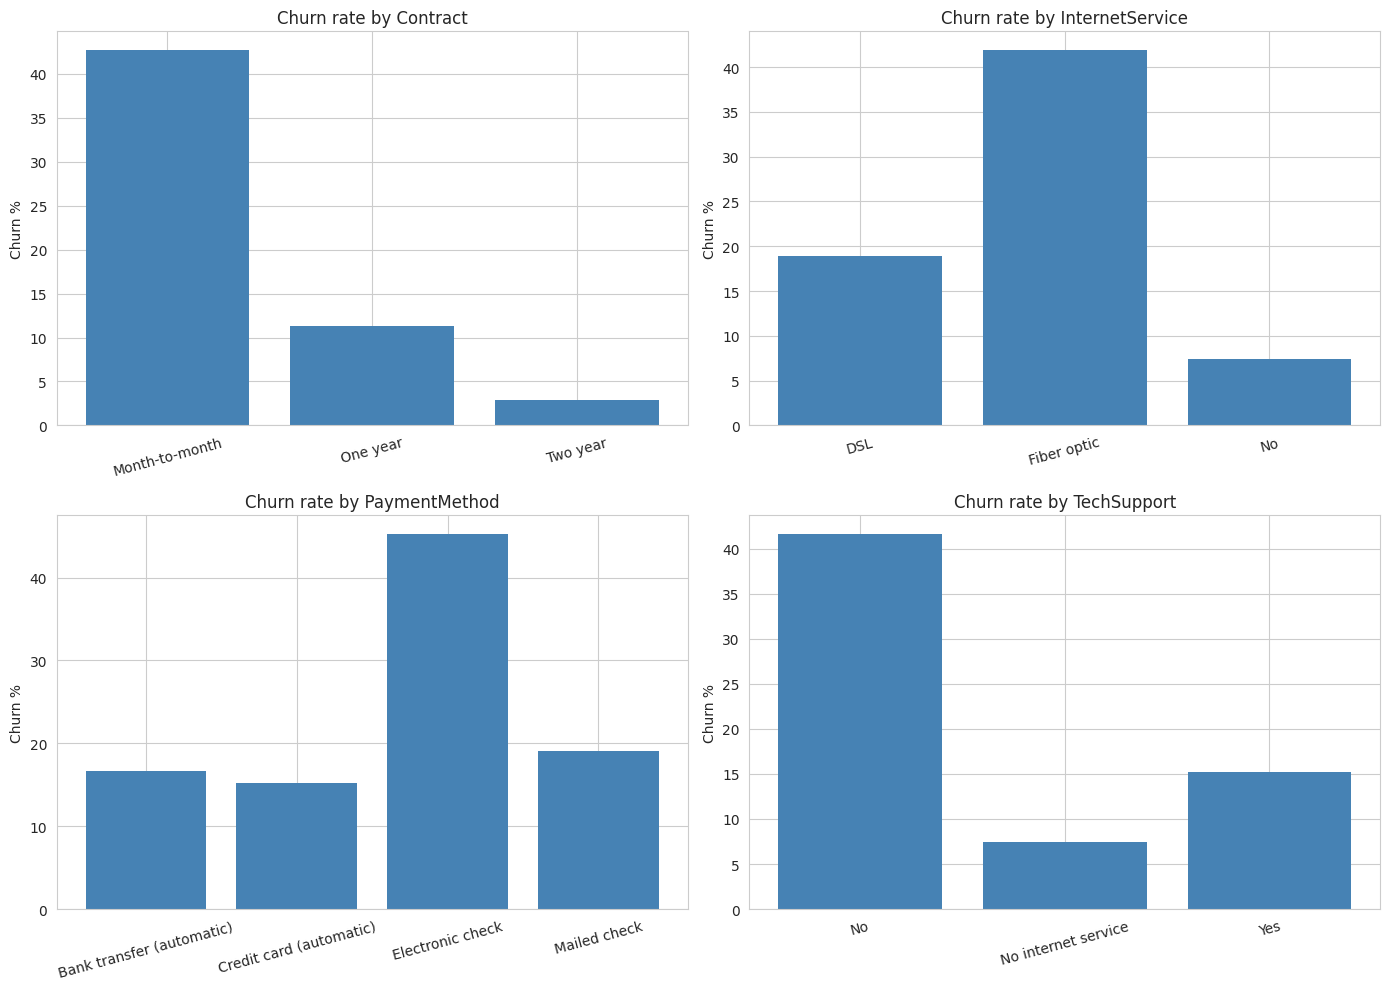

In [31]:
cat_cols =  ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes =plt.subplots(2,2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate=(
        df.groupby(col)['Churn'].apply(lambda x:(x =='Yes').mean() * 100).reset_index() 
    )
    churn_rate.columns = [col, 'ChurnRate']
    ax.bar(churn_rate[col], churn_rate['ChurnRate'], color = 'steelblue', edgecolor= 'none')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn %')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

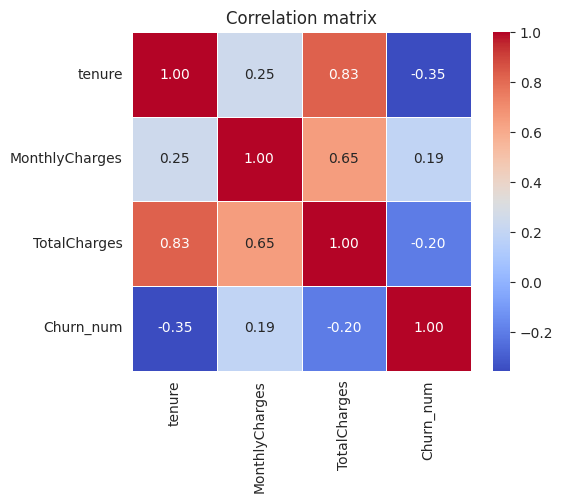

In [26]:
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [30]:
df.to_csv('/home/aniketnerali16/new/WA_Fn-UseC_-Telco-Customer-Churn-Cleaned.csv', index=False)
print("Saved churn_cleaned.csv — ready for SQL phase!")

Saved churn_cleaned.csv — ready for SQL phase!
